# Week 7 — Train Language ID Model(Code-Switching Token Classification)


In [1]:
!pip install -q transformers torch datasets seqeval accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## Step 1 — Load and prepare dataset

In [4]:
# Load your dataset directly from HuggingFace Hub
from datasets import load_dataset
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
raw = load_dataset('qadeesanoor/code-switching-codesaviours-si26-qadeesanoor', split='train')
df = raw.to_pandas()
print(f'Total rows (words): {len(df)}')
print(f'Total sentences: {df["sentence"].nunique()}')
print(df['label'].value_counts())

# Create label mapping
label2id = {'URD': 0, 'ENG': 1, 'MIX': 2}
id2label = {0: 'URD', 1: 'ENG', 2: 'MIX'}

# Group by sentence, preserving original word order
sentences = (
    df.groupby('sentence', sort=False)
    .apply(lambda x: {'words': x['word'].tolist(), 'labels': x['label'].tolist()}, include_groups=False)
    .tolist()
)
# Split into train and test
train_data, test_data = train_test_split(sentences, test_size=0.2, random_state=42)
print(f'Training sentences: {len(train_data)}')
print(f'Testing sentences: {len(test_data)}')

if len(sentences) < 500:
    print('\nWARNING: dataset is small (<500 sentences). Expect unstable/overfit eval metrics. '
          'Treat F1 scores as provisional, not a real performance claim.')

Total rows (words): 4960
Total sentences: 501
label
URD    2664
ENG    2021
MIX     275
Name: count, dtype: int64
Training sentences: 400
Testing sentences: 101


## Step 2 — Fine-tune XLM-RoBERTa for token classification

In [5]:
import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger('transformers').setLevel(logging.ERROR)
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification,
    TrainingArguments, Trainer, DataCollatorForTokenClassification
)
from datasets import Dataset
import numpy as np
from sklearn.metrics import classification_report as sk_classification_report, f1_score as sk_f1_score

model_name = 'xlm-roberta-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

def tokenize_and_align_labels(examples):
    tokenized = tokenizer(examples['words'], truncation=True, is_split_into_words=True)
    labels = []
    for i, label in enumerate(examples['labels']):
        word_ids = tokenized.word_ids(batch_index=i)
        label_ids = []
        prev_word = None
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_word:
                label_ids.append(label2id[label[word_id]])
            else:
                label_ids.append(-100)
            prev_word = word_id
        labels.append(label_ids)
    tokenized['labels'] = labels
    return tokenized

def to_hf_dataset(data):
    return Dataset.from_dict({
        'words': [d['words'] for d in data],
        'labels': [d['labels'] for d in data]
    })

train_ds = to_hf_dataset(train_data).map(tokenize_and_align_labels, batched=True)
test_ds = to_hf_dataset(test_data).map(tokenize_and_align_labels, batched=True)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2)

    true_predictions = []
    true_labels = []
    for pred, lab in zip(predictions, labels):
        for p, l in zip(pred, lab):
            if l != -100:
                true_predictions.append(id2label[p])
                true_labels.append(id2label[l])

    report = sk_classification_report(
        true_labels, true_predictions,
        labels=['URD', 'ENG', 'MIX'],
        output_dict=True, zero_division=0
    )

    return {
        'overall_f1': sk_f1_score(true_labels, true_predictions, average='weighted', zero_division=0),
        'f1_URD': report['URD']['f1-score'],
        'f1_ENG': report['ENG']['f1-score'],
        'f1_MIX': report['MIX']['f1-score'],
    }

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model='overall_f1',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=tokenizer,
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=compute_metrics,
)

print('Starting training...')
trainer.train()
print('Training complete!')

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

...

{'loss': '0.03689', 'grad_norm': '3.897', 'learning_rate': '1.84e-05', 'epoch': '3.2'}
{'loss': '0.0402', 'grad_norm': '14.33', 'learning_rate': '1.44e-05', 'epoch': '3.6'}
{'loss': '0.03293', 'grad_norm': '3.404', 'learning_rate': '1.04e-05', 'epoch': '4'}
{'eval_loss': '0.05193', 'eval_overall_f1': '0.984', 'eval_f1_URD': '0.9953', 'eval_f1_ENG': '0.9813', 'eval_f1_MIX': '0.8791', 'eval_runtime': '0.1833', 'eval_samples_per_second': '551', 'eval_steps_per_second': '70.92', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.02043', 'grad_norm': '0.6184', 'learning_rate': '6.4e-06', 'epoch': '4.4'}
{'loss': '0.02026', 'grad_norm': '0.4215', 'learning_rate': '2.4e-06', 'epoch': '4.8'}
{'eval_loss': '0.0484', 'eval_overall_f1': '0.9859', 'eval_f1_URD': '0.9972', 'eval_f1_ENG': '0.9836', 'eval_f1_MIX': '0.8764', 'eval_runtime': '0.2339', 'eval_samples_per_second': '431.8', 'eval_steps_per_second': '55.58', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '202.7', 'train_samples_per_second': '9.866', 'train_steps_per_second': '0.617', 'train_loss': '0.145', 'epoch': '5'}
Training complete!


## Step 3 — Evaluate and print final per-label scores

In [6]:
eval_results = trainer.evaluate()
print('Final evaluation metrics:')
for k, v in eval_results.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

{'eval_loss': '0.0484', 'eval_overall_f1': '0.9859', 'eval_f1_URD': '0.9972', 'eval_f1_ENG': '0.9836', 'eval_f1_MIX': '0.8764', 'eval_runtime': '0.3102', 'eval_samples_per_second': '325.6', 'eval_steps_per_second': '41.91', 'epoch': '5'}
Final evaluation metrics:
  eval_loss: 0.0484
  eval_overall_f1: 0.9859
  eval_f1_URD: 0.9972
  eval_f1_ENG: 0.9836
  eval_f1_MIX: 0.8764
  eval_runtime: 0.3102
  eval_samples_per_second: 325.6210
  eval_steps_per_second: 41.9120
  epoch: 5.0000


## Step 4 — Graphic view of Evaluation

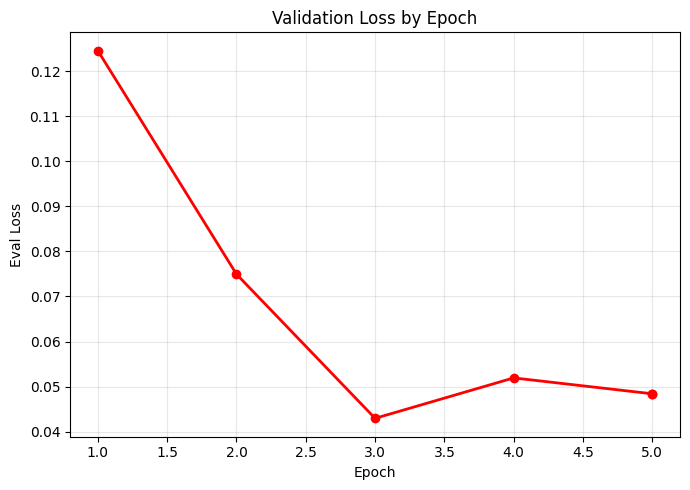

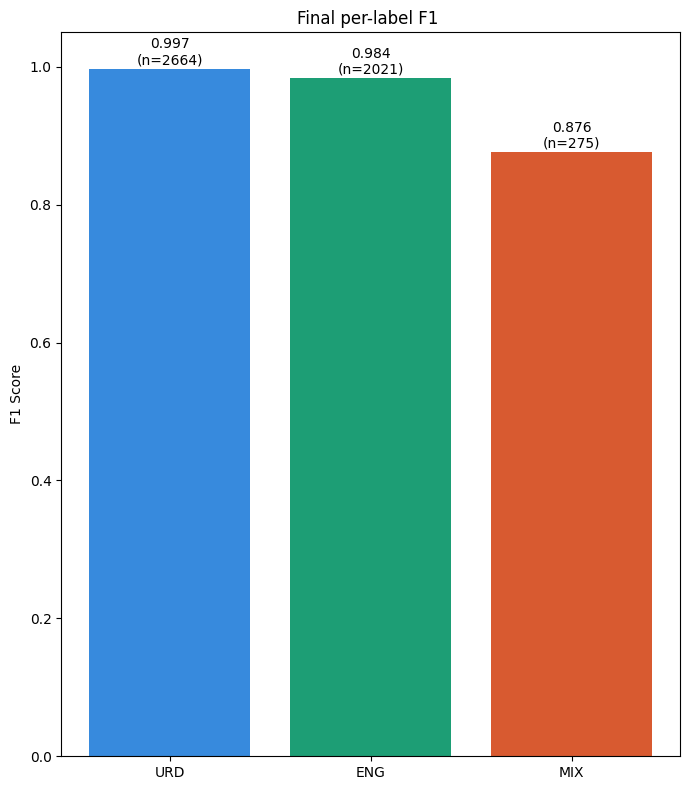

In [7]:
import matplotlib.pyplot as plt

# Extract per-epoch metrics from Trainer's log history
log_history = trainer.state.log_history

epochs = []
eval_losses = []

for entry in log_history:
    if 'eval_overall_f1' in entry:
        epochs.append(entry['epoch'])
        eval_losses.append(entry.get('eval_loss', None))

# Plot: Eval loss over epochs
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(epochs, eval_losses, marker='o', color='red', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Eval Loss')
ax.set_title('Validation Loss by Epoch')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart: final per-label F1 with sample-size annotation
final_scores = {
    'URD': eval_results.get('eval_f1_URD', 0),
    'ENG': eval_results.get('eval_f1_ENG', 0),
    'MIX': eval_results.get('eval_f1_MIX', 0),
}
label_counts = combined_df['label'].value_counts() if 'combined_df' in dir() else df['label'].value_counts()

fig2, ax2 = plt.subplots(figsize=(7, 8))
bars = ax2.bar(final_scores.keys(), final_scores.values(), color=['#378ADD', '#1D9E75', '#D85A30'])
for bar, label in zip(bars, final_scores.keys()):
    height = bar.get_height()
    n = label_counts.get(label, 0)
    ax2.annotate(f'{height:.3f}\n(n={n})', xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10)
ax2.set_ylabel('F1 Score')
ax2.set_title('Final per-label F1 ')
ax2.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('final_f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Save and push to HuggingFace Hub

In [8]:
from huggingface_hub import notebook_login
notebook_login()

repo_name = 'code-switching-codesaviours-si26-qadeesa'

model.push_to_hub(repo_name)
tokenizer.push_to_hub(repo_name)
print(f'Model published at: https://huggingface.co/qadeesanoor/code-switching-codesaviours-si26-qadeesa')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ..._mq_oqp/model.safetensors:   0%|          | 13.6kB / 1.11GB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mplqm3o7zu/tokenizer.json: 100%|##########| 17.1MB / 17.1MB            

Model published at: https://huggingface.co/qadeesanoor/code-switching-codesaviours-si26-qadeesa
